# 06 — Demo: Single Container Loading (un camión)

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_single_container_instance.json` — catálogo P1–P5 (30 uds), **1 contenedor altura 70**.

**Flujo:** 1) Presentar el problema → 2) Ejecutar un algoritmo → 3) Ver la solución → 4) Benchmark.

A diferencia del Container Loading (NB05), aquí solo hay **un camión**. La altura reducida fuerza
un trade-off visible: `best_fit` densifica (~13 piezas, 94% util) vs `first_fit` empaca más (~16, 89%).


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from _shared.loaders import load_showcase_instance, build_single_container_request
from packing_services.schemas.requests import PackRequest

instance = load_showcase_instance('SINGLE_CONTAINER_LOADING')
display.show_problem_overview(instance)


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,70,500,560000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


Restricciones activas: non_overlap, containment, allow_rotation, max_weight


In [3]:
data = build_single_container_request(instance, 'best_fit_decreasing_3d')
request = PackRequest(**data)
containers = request.containers
print('--- Solución (algoritmo: best_fit_decreasing_3d) ---')
solution = runners.run_pack(data)
display.show_kpis(solution.metrics, valid=solution.validation_report.is_valid, algorithm=solution.algorithm_name)


2026-07-12 15:37:18,435 | INFO    | packing_services.services.packing_service | pack request_id=showcase-scl-001 algorithm=best_fit_decreasing_3d items=30 containers=1


2026-07-12 15:37:18,447 | INFO    | packing_services.services.packing_service | pack done request_id=showcase-scl-001 status=SolutionStatus.PARTIAL packed=13 unpacked=17 util=0.943


--- Solución (algoritmo: best_fit_decreasing_3d) ---


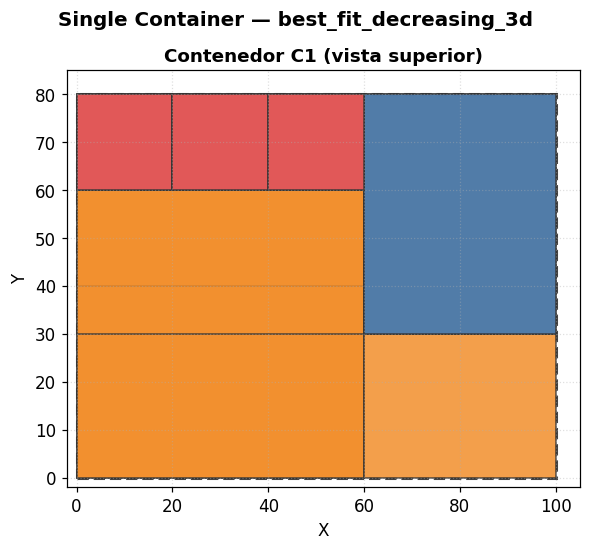

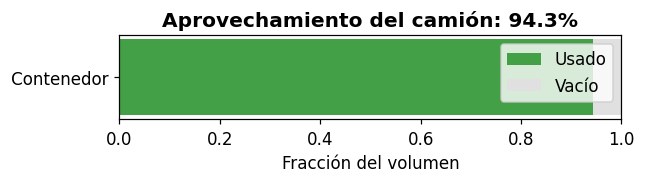

In [4]:
fig = viz.plot_all_container_views(solution, containers, title_prefix='Single Container')
if fig: plt.show()
fig = viz.plot_utilization_bar(solution.metrics.volume_utilization, title='Aprovechamiento del camión')
plt.show()


═══ BENCHMARK HOMOGÉNEO (Single Container) ═══
Motores comparables — Single Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
3,first_fit_decreasing_3d,First Fit Decreasing 3D,No


Nota: best_fit/single ~13 emp. (94% util) vs first_fit ~16 (89%)
Benchmark — Single Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,single_container_constructive,94.3%,13,17,Sí,0.0096
2,best_fit_decreasing_3d,94.3%,13,17,Sí,0.0137
3,first_fit_decreasing_3d,89.3%,16,14,Sí,0.0059


Ranking Single Container Loading: (1) válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor tiempo.


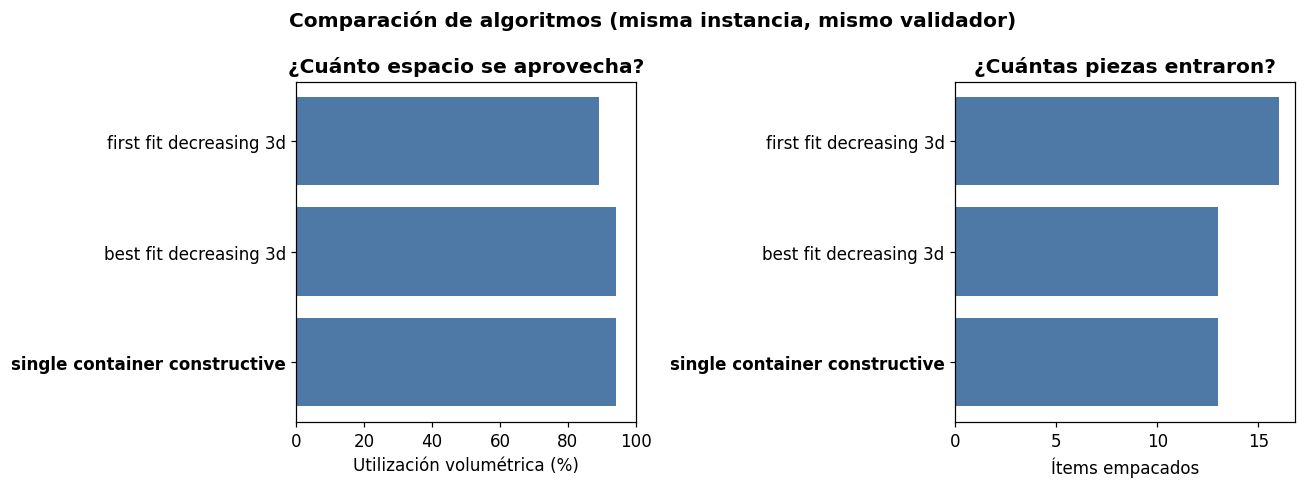

BenchmarkResponse(request_id='benchmark-scl-001', results=[BenchmarkEngineResult(engine='single_container_constructive', status='partial', is_valid=True, metrics=Metrics(volume_utilization=0.942857, waste_volume=0.057143, containers_used=1, items_packed=13, items_unpacked=17, packed_volume=528000.0, unpacked_volume=680750.0, total_item_volume=1208750.0, loaded_weight=59.0, execution_time_seconds=0.009617, constraint_violations=0), validation_report=ValidationReport(is_valid=True, violations=[]), solution=PackingSolution(request_id='benchmark-scl-001', status=<SolutionStatus.PARTIAL: 'partial'>, problem_type=<ProblemType.SINGLE_CONTAINER_LOADING: 'SINGLE_CONTAINER_LOADING'>, algorithm_name='single_container_constructive', packed_items=[PackedItem(item_id='P2#1', container_id='C1', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0), PackedItem(item_id='P2#2', container_id='C1', position=Point3D(x=0.0, y=0.0, z=40.0), orientat

In [5]:
print('═══ BENCHMARK HOMOGÉNEO (Single Container) ═══')
display.run_and_show_showcase_benchmark('SINGLE_CONTAINER_LOADING', instance)


**Siguiente:** `07_cartonization.ipynb`
